# Random Forest

Last week, we practiced `decision trees`. We observed that decision trees have an overfitting and variance problem as the tree grows larger and larger. We offer a new method that will solve problems and limitations of decision trees: **Random Forest**. As the name suggests, Random Forest incorporates multiple decision trees and based on random subset of features with bootstrapping approach.

Random Forest is a *supervised* machine learning algorithm which can be used for both *classification* and *regression* problems. We run many decision trees independently and aggregate the outputs with a voting based approach.

![alt text](https://upload.wikimedia.org/wikipedia/commons/7/76/Random_forest_diagram_complete.png)

While offering a solution to decision tree limitations, Random Forest lose the interpretability of decision trees which we will see in examples.


In [ ]:
from google.colab import drive
drive.mount("./drive", force_remount=True)

path_prefix = "./drive/My Drive"

Mounted at ./drive


In [ ]:
import numpy as np
import pandas as pd
from os.path import join
import matplotlib.pyplot as plt

%matplotlib inline

# Let's Try Classification with Random Forest

Last time we have done Decision Tree classification using Titanic survival dataset. To be able to understand the difference let's do similar experiment for both Decision Tree Classifier and Random Forest Classifier.

Problem is multinomial classification. The aim is to predict the handwritten digit from 0 to 9.

![alt text](https://programmer.help/images/blog/494a7662440ea97b9e1a6dc815e789f5.jpg)

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.keys()

#Split the dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.25,
                                                random_state=42)

In [ ]:
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

#Decision Tree Training
model_dt = tree.DecisionTreeClassifier(random_state=42) #Create decision tree classifier object
model_dt.fit(X_train, y_train) #train the classifier using the training data

#Random Forest Training(In new version default of estimators will be 100)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

We specified the random_state to 42 so that as everybody doing the example we get same results. Also for Random Forest we made n_estimators 100 since in the updated model default n_estimators will be 100. Other than these we did not specify any parameters when we build our decision tree or Random Forest but the model has many parameters. Let's go to the [documentation page](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) of the Random Forest in scikit-learn and see what those are.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve

#Decision Tree Testing
dt_predictions = model_dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_predictions)

rf_predictions = model_rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_predictions)

print("Decision Tree Accuracy:"+str(dt_acc))
print("Random Forest Accuracy:"+str(rf_acc))


Decision Tree Accuracy:0.8577777777777778
Random Forest Accuracy:0.9711111111111111


We can easily see that Random Forest outperforms Decision Tree. Now let's try to prove another point. 
Suppose we want to avoid overfitting in general and decide to use max_depth as 2 in decision tree and adjust random forest also.

In [ ]:
#Decision Tree Training with max_depth=2
model_dt = tree.DecisionTreeClassifier(max_depth=2) #Create decision tree classifier object
model_dt.fit(X_train, y_train) #train the classifier using the training data

#Random Forest Training(In new version default of estimators will be 100) with max_depth=2
model_rf = RandomForestClassifier(n_estimators=100,max_depth=2)
model_rf.fit(X_train, y_train,)

#Decision Tree Testing with max_depth=2
dt_predictions = model_dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_predictions)

#Random Forest Testing with max_depth=2
rf_predictions = model_rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_predictions)


print("Decision Tree Train Accuracy:"+str(accuracy_score(y_train, model_dt.predict(X_train))))
print("Random Forest Train Accuracy:"+str(accuracy_score(y_train, model_rf.predict(X_train))))

print("Decision Tree Test Accuracy:"+str(dt_acc))
print("Random Forest Test Accuracy:"+str(rf_acc))

Decision Tree Train Accuracy:0.3110616184112843
Random Forest Train Accuracy:0.8307349665924276
Decision Tree Test Accuracy:0.26222222222222225
Random Forest Test Accuracy:0.86


It clearly shows that when we try to avoid overfitting by reducing variance(depth) in decision tree in decision tree, the accuracy will suffer. On the other hand, since we have 100 random trees in random forest, impact to this model will be less than Decision Tree.

To understand our result better let's look at **confusion matrix** colors.

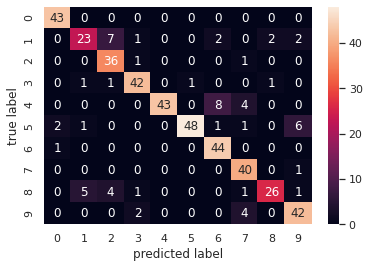

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
sns.set()
mat = confusion_matrix(y_test, rf_predictions)
sns.heatmap(mat, annot=True, fmt='d')
plt.xlabel('predicted label')
plt.ylabel('true label');

Let's understand what is the confusion matrix.

##Confusion Matrix

*A confusion matrix is a specific table layout that allows visualization of the performance of an algorithm, with two dimensions (“actual” and “predicted”), and identical sets of “classes” in both dimensions.* [[1]](https://en.wikipedia.org/wiki/Confusion_matrix)

Confusion Matrix is a performance measurement for machine learning classification. Calculating a confusion matrix can give you a better idea of what your classification model is getting right and what types of errors it is making.



---




[[2]](https://www.dataschool.io/simple-guide-to-confusion-matrix-terminology/)Let's start with an example confusion matrix for a binary classifier (though it can easily be extended to the case of more than two classes)

![alt text](https://www.dataschool.io/content/images/2015/01/confusion_matrix_simple2.png)



*   There are two possible predicted classes: "yes" and "no".
*   The classifier made a total of 165 predictions
*   Out of those 165 cases, the classifier predicted "yes" 110 times, and "no" 55 times.
*   In reality, we have 105 "yes" and 60 "no".



Let's now define the most basic terms, which are whole numbers (not rates):

*   **true positives (TP):** These are cases in which we predicted yes and they are actually "yes"
*   **true negatives (TN):** We predicted no and they are actually "no"
*   **false positives (FP):** We predicted yes, but they aren't actually "yes" (Also known as a "Type I error.")
*   **false negatives (FN):** We predicted no, but they  are actually "yes" (Also known as a "Type II error.")


![alt text](https://www.dataschool.io/content/images/2015/01/confusion_matrix2.png)

**Accuracy:** Overall, how often is the classifier correct?
*   (TP+TN)/total = (100+50)/165 = 0.91

**Misclassification Rate:** Overall, how often is it wrong?
*   (FP+FN)/total = (10+5)/165 = 0.09
*   equivalent to (1 - Accuracy)
*   also known as "Error Rate"

**Recall:** When it's actually yes, how often does it predict yes?
*   TP/actual yes = 100/105 = 0.95
*   also known as "Sensitivity" or "True Positive Rate"

**Precision:** When it predicts yes, how often is it correct?
*   TP/predicted yes = 100/110 = 0.91


**F1-score:** 
*   = 2\*recall\*precision/(recall+precision)

### Exercise: Calculate performance metrics using confusion matrix

Instructions

- Once you are assigned to a breakout room, discuss among yourselves to decide who will be sharing the screen to collectively develop a solution. Actively participate in the group discussion.
- For your questions, you may use the `request help` button on the Zoom menu.

---

In this exercise, you are going to calculate accuracy, precision, recall and f1-score values.

- First, calculate accuracy and print it.

- Calculate precision , recall and f-score for each digits

- Create a dataframe with your calculations
  - `columns= ["precision",	"recall",	"f-score"]`

- Use `classification_report` to check your results.

 

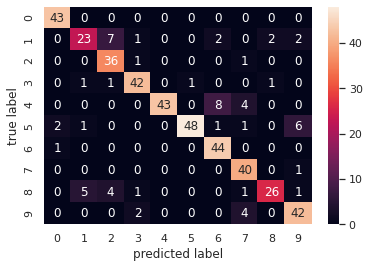

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
sns.set()
mat = confusion_matrix(y_test, rf_predictions)
sns.heatmap(mat, annot=True, fmt='d')
plt.xlabel('predicted label')
plt.ylabel('true label');

In [ ]:
from sklearn.metrics import classification_report

# your code

## Which features were the most effective?

Feature importance refers to techniques that assign a score to input features based on **how useful they are at predicting a target variable**.


[[3]](https://towardsdatascience.com/explaining-feature-importance-by-example-of-a-random-forest-d9166011959e)Knowing feature importance indicated by machine learning models can benefit you in multiple ways, for example:

*   by getting a better understanding of the model’s logic you can not only verify it being correct but also work on improving the model by focusing only on the important variables
*   the above can be used for variable selection — you can remove x variables that are not that significant and have similar or better performance in much shorter training time
*   in some business cases it makes sense to sacrifice some accuracy for the sake of interpretability. For example, when a bank rejects a loan application, it must also have a reasoning behind the decision, which can also be presented to the customer

You can check these resources to understand better how is calculating feature importance
*    [Resource 1](https://towardsdatascience.com/the-mathematics-of-decision-trees-random-forest-and-feature-importance-in-scikit-learn-and-spark-f2861df67e3 )  
*    [Resource 2](https://scikit-learn.org/stable/modules/ensemble.html#feature-importance-evaluation)

In [ ]:
#Assume pixels are our features. Model has 8x8=64 features. Create a list with length 64 where each element stands for one pixel.
feature_list = list(range(digits.data.shape[1]))

# Get importance list from model
importances = list(model_rf.feature_importances_)

# Create list of tuples by combining(zip) feature list and and importance list 
feature_importance = [(feature, round(importance, 2)) for feature, importance in zip(feature_list, importances)]

# Sort features by importance
feature_importances = sorted(feature_importance, key = lambda x: x[1], reverse = True)

# Print top 5 features 
for pair in feature_importances[:5]:
  print("Variable: {:2}   Importance: {}".format(*pair))

Variable: 21   Importance: 0.09
Variable: 36   Importance: 0.09
Variable: 28   Importance: 0.08
Variable: 42   Importance: 0.08
Variable: 43   Importance: 0.08


Text(0.5, 1.0, 'Feature Importances')

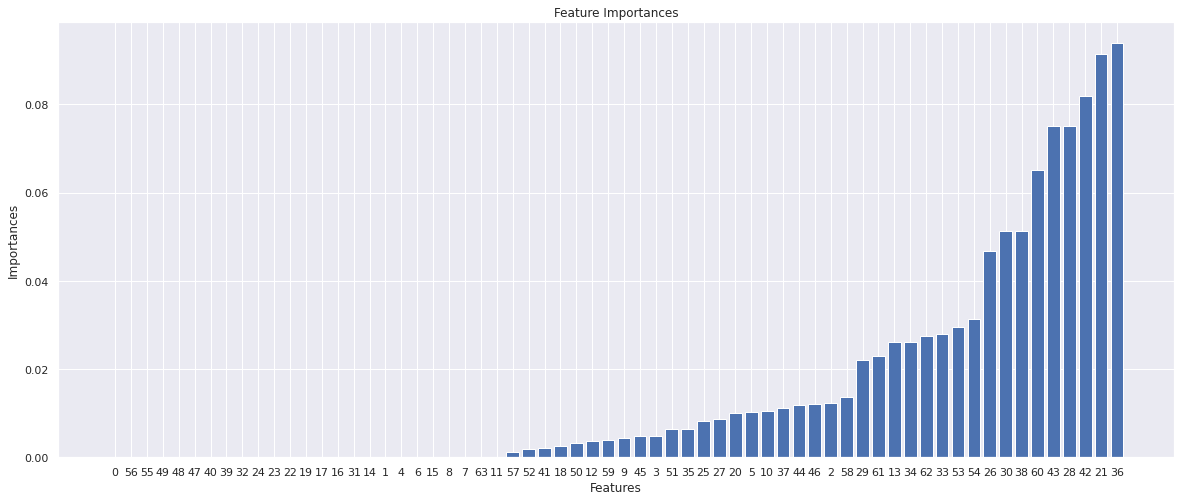

In [ ]:
fig, ax = plt.subplots(figsize=(20, 8))
index=np.argsort(importances)
arr_sorted=[]
for i in index:
  arr_sorted.append(importances[i])

x=np.arange(0,len(importances))
ax.set_xticks(x)
ax.set_xticklabels(index)
ax.bar(x,arr_sorted)
plt.xlabel("Features")
plt.ylabel("Importances")
plt.title("Feature Importances")

### Exercise: Effects of features on the accuracy value

In this exercise you will use titanic dataset `titanic.csv` from last week. You will create a random forest model that predicts the survival status of a given passenger. 

- Create a random forest model to predict survival status, set `n_estimators` as 100

- Find and print the feature importances

- Train your model without the less 2 important features and see the effect on the accuracy value

- Train your model without the most important feature and see the effect on the accuracy value






In [ ]:
filename = "titanic.csv"
df = pd.read_csv(join(path_prefix, filename))

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score

df = df.drop(["name"], axis=1)

encoder = OrdinalEncoder()
df["gender"] = encoder.fit_transform(df[["gender"]])

y= df["survived"]
X= df.drop(["survived"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [ ]:
# your code